 Part III: Spam vs Ham Text Classification



## 0. Setup and Imports

In [1]:
# Install libraries (run once)
# !pip install numpy==1.23.5 gensim --quiet
# !pip install nltk wordcloud gradio --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1-4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

[nltk_data] Error loading omw-1-4: Package 'omw-1-4' not found in
[nltk_data]     index


TensorFlow: 2.20.0 | NumPy: 2.0.2
GPU: []


In [ ]:
# Install libraries (run once)
# !pip install numpy==1.23.5 gensim --quiet
# !pip install nltk wordcloud gradio --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1-4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

[nltk_data] Error loading omw-1-4: Package 'omw-1-4' not found in
[nltk_data]     index


TensorFlow: 2.20.0 | NumPy: 2.0.2
GPU: []


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load and Explore Dataset

In [3]:
df = pd.read_csv("/content/drive/MyDrive/spamvsham.csv", encoding='latin-1', header=0,
                 names=['label','text','c','d','e'], usecols=['label','text'])

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())
print(f"Spam ratio: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")

Shape: (5572, 2)
Missing values: 0
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
Spam ratio: 13.4%


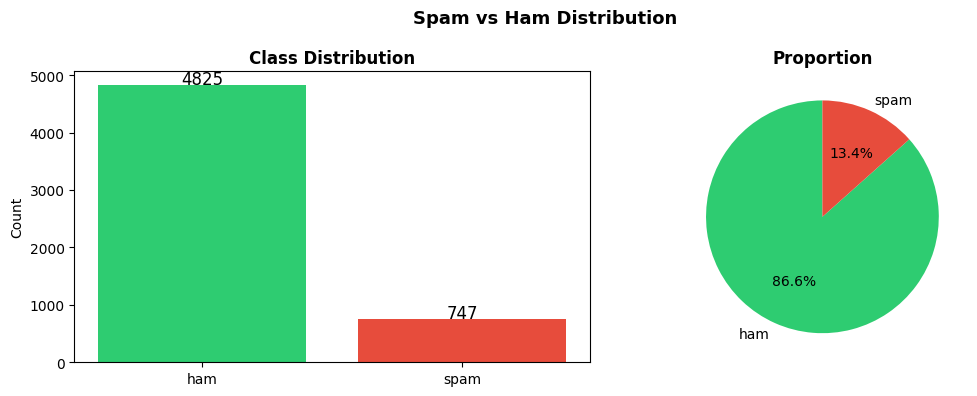

Observation: Dataset is IMBALANCED - 87% Ham, 13% Spam.
This means accuracy alone is misleading. We must check F1-score for spam class.


In [4]:
# Class distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
counts = df['label'].value_counts()
ax1.bar(counts.index, counts.values, color=['#2ecc71','#e74c3c'])
ax1.set_title("Class Distribution", fontweight='bold')
ax1.set_ylabel("Count")
for i, (k, v) in enumerate(counts.items()):
    ax1.text(i, v+20, str(v), ha='center', fontsize=12)
ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'], startangle=90)
ax2.set_title("Proportion", fontweight='bold')
plt.suptitle("Spam vs Ham Distribution", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("label_distribution.png", dpi=150); plt.show()
print("Observation: Dataset is IMBALANCED - 87% Ham, 13% Spam.")
print("This means accuracy alone is misleading. We must check F1-score for spam class.")

Message length stats by class:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


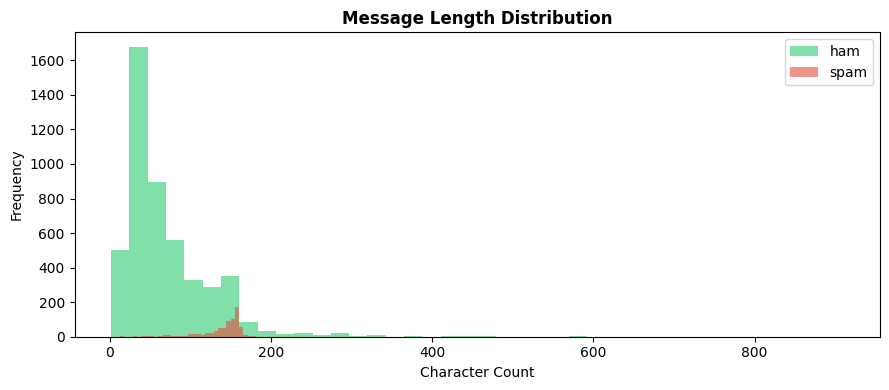

Observation: Spam messages tend to be longer (promotional language, links, offers).


In [5]:
# Text length analysis
df['text_len'] = df['text'].apply(len)
print("Message length stats by class:")
print(df.groupby('label')['text_len'].describe())
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [('ham','#2ecc71'),('spam','#e74c3c')]:
    ax.hist(df[df['label']==label]['text_len'], bins=40, alpha=0.6, label=label, color=color)
ax.set_title("Message Length Distribution", fontweight='bold')
ax.set_xlabel("Character Count"); ax.set_ylabel("Frequency"); ax.legend()
plt.tight_layout(); plt.show()
print("Observation: Spam messages tend to be longer (promotional language, links, offers).")

## 2. Text Preprocessing

In [6]:
# Contraction mapping
CONTRACTIONS = {
    "don't":"do not","does not":"does not","can't":"cannot","won't":"will not",
    "i'm":"i am","i've":"i have","it's":"it is","you're":"you are",
    "that's":"that is","didn't":"did not","isn't":"is not","wasn't":"was not",
    "we're":"we are","they're":"they are","i'll":"i will","you'll":"you will",
    "he's":"he is","she's":"she is","we've":"we have","they've":"they have"
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()                              # lowercase
    text = expand_contractions(text)                      # expand contractions
    text = re.sub(r'http\S+|www\.\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                     # remove mentions
    text = re.sub(r'#\w+', '', text)                     # remove hashtags
    text = re.sub(r'\d+', '', text)                      # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("Original: ", df['text'].iloc[2])
print("Cleaned:  ", df['clean_text'].iloc[2])
print()
print("Original: ", df['text'].iloc[3])
print("Cleaned:  ", df['clean_text'].iloc[3])

Original:  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned:   free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over

Original:  U dun say so early hor... U c already then say...
Cleaned:   dun say early hor already say


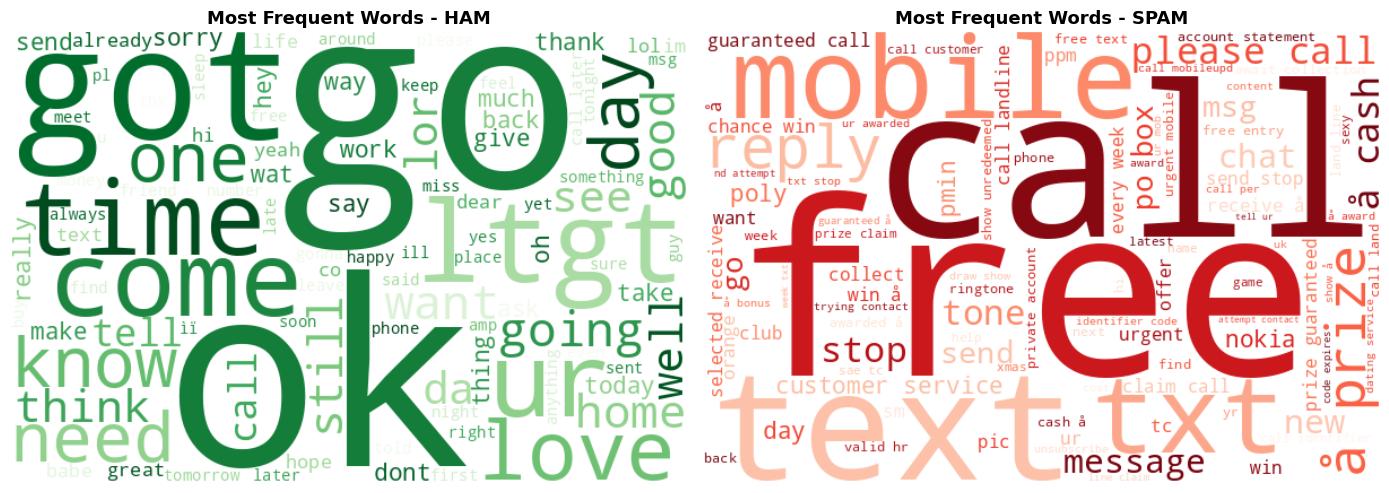

Top ham words: ['get', 'ltgt', 'go', 'ok', 'come', 'know', 'call', 'ur', 'got', 'like', 'good', 'day', 'time', 'love', 'want']
Top spam words: ['call', 'å£', 'free', 'txt', 'ur', 'text', 'mobile', 'stop', 'claim', 'reply', 'prize', 'get', 'tone', 'service', 'nokia']


In [7]:
# WordCloud visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, cmap in [(axes[0],'ham','Greens'),(axes[1],'spam','Reds')]:
    text = ' '.join(df[df['label']==label]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Most Frequent Words - {label.upper()}", fontsize=13, fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.savefig("wordclouds.png", dpi=150); plt.show()

# Top 15 words per class
for label in ['ham', 'spam']:
    words = ' '.join(df[df['label']==label]['clean_text']).split()
    top15 = [w for w, _ in Counter(words).most_common(15)]
    print(f"Top {label} words: {top15}")

## 3. Tokenization and Sequence Padding

In [8]:
# Encode labels: ham=0, spam=1
df['label_num'] = (df['label'] == 'spam').astype(int)

# Train/test split - stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_num'],
    test_size=0.20, random_state=42, stratify=df['label_num']
)
print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")
print(f"Train spam%: {y_train.mean()*100:.1f}%  |  Test spam%: {y_test.mean()*100:.1f}%")

Train: 4457 samples  |  Test: 1115 samples
Train spam%: 13.4%  |  Test spam%: 13.4%


In [9]:
# Tokenize
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # fit ONLY on train data!

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)
word_index = tokenizer.word_index

print(f"Unique words found: {len(word_index):,}")
print(f"Vocabulary used:    {VOCAB_SIZE:,} (top words)")
print(f"Sample sequence: {train_seqs[0]}")

Unique words found: 6,979
Vocabulary used:    10,000 (top words)
Sample sequence: [22, 219, 3137]


In [10]:
# Pad sequences using 90th percentile length
lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(lengths, 90))
print(f"90th percentile sequence length: {MAX_LEN} tokens -> using as MAX_LEN")
print(f"Mean: {np.mean(lengths):.1f}, Max: {max(lengths)}, Min: {min(lengths)}")

X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")
print("Padding='post' adds zeros at the end. Truncating='post' cuts long sequences from end.")

90th percentile sequence length: 16 tokens -> using as MAX_LEN
Mean: 8.3, Max: 79, Min: 0
Train shape: (4457, 16)
Test shape:  (1115, 16)
Padding='post' adds zeros at the end. Truncating='post' cuts long sequences from end.


## 4. Model Building

In [11]:
# Shared settings
EMBED_DIM  = 64
RNN_UNITS  = 64
LSTM_UNITS = 64
EPOCHS     = 30
BATCH_SIZE = 64

callbacks_list = [EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)]

### Model 1: Simple RNN

SimpleRNN processes sequence left to right but suffers from vanishing gradient on long sequences.

In [12]:
model1 = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding'),
    layers.SimpleRNN(RNN_UNITS, return_sequences=False, name='rnn'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='SimpleRNN_Model')

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, callbacks=callbacks_list, verbose=1
)
time1 = time.time() - t0
print(f"SimpleRNN training time: {time1:.1f}s")

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9227 - loss: 0.2315 - val_accuracy: 0.9619 - val_loss: 0.1412
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9888 - loss: 0.0553 - val_accuracy: 0.9753 - val_loss: 0.1047
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9933 - loss: 0.0335 - val_accuracy: 0.9753 - val_loss: 0.1177
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9965 - loss: 0.0165 - val_accuracy: 0.9686 - val_loss: 0.1035
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9975 - loss: 0.0163 - val_accuracy: 0.9731 - val_loss: 0.1336
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9985 - loss: 0.0115 - val_accuracy: 0.9798 - val_loss: 0.1190
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9978 - loss: 0.0105 - val_accuracy: 0.9753 - val_loss: 0.1370
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9988 - loss: 0.0071 - val_accuracy: 0.9753 - v

### Model 2: LSTM

LSTM uses gates (forget, input, output) to selectively remember and forget information. Handles long-range dependencies much better than SimpleRNN.

In [13]:
model2 = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding'),
    layers.LSTM(LSTM_UNITS, return_sequences=True,  name='lstm1'),
    layers.Dropout(0.3),
    layers.LSTM(32, return_sequences=False, name='lstm2'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='LSTM_Model')

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

t0 = time.time()
history2 = model2.fit(
    X_train_pad, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, callbacks=callbacks_list, verbose=1
)
time2 = time.time() - t0
print(f"LSTM training time: {time2:.1f}s")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9038 - loss: 0.2882 - val_accuracy: 0.9574 - val_loss: 0.1562
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9835 - loss: 0.0644 - val_accuracy: 0.9709 - val_loss: 0.0932
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9955 - loss: 0.0253 - val_accuracy: 0.9731 - val_loss: 0.1195
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9950 - loss: 0.0183 - val_accuracy: 0.9753 - val_loss: 0.0939
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9983 - loss: 0.0081 - val_accuracy: 0.9619 - val_loss: 0.1269
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9995 - loss: 0.0034 - val_accuracy: 0.9664 - val_loss: 0.1415
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9664 - val_loss: 0.1729
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
LSTM training time: 22.3s


### Model 3: LSTM + Pretrained GloVe Embeddings

GloVe vectors encode semantic relationships learned from billions of words. The embedding layer starts already knowing that 'free' and 'win' are related, helping the model detect spam patterns faster.

In [15]:
# Download GloVe (takes ~2 minutes on Colab)
!pip install gensim --quiet
import gensim.downloader as api
print("Downloading GloVe-50 (~66MB)...")
glove_model = api.load('glove-wiki-gigaword-50')
EMBED_W2V = 50

# Build embedding matrix from GloVe
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_W2V))
found, not_found = 0, 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
            found += 1
        else:
            not_found += 1
print(f"Found in GloVe: {found:,} | Not found: {not_found:,}")
print(f"Coverage: {found/(found+not_found)*100:.1f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.2 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
Found in GloVe: 5,059 | Not found: 1,920
Coverage: 72.5%


In [16]:
model3 = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_W2V,
                     weights=[embedding_matrix], input_length=MAX_LEN,
                     trainable=False, name='glove_embedding'),
    layers.LSTM(LSTM_UNITS, return_sequences=True,  name='lstm1'),
    layers.Dropout(0.3),
    layers.LSTM(32, return_sequences=False, name='lstm2'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='LSTM_GloVe_Model')

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, callbacks=callbacks_list, verbose=1
)
time3 = time.time() - t0
print(f"LSTM+GloVe training time: {time3:.1f}s")

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8913 - loss: 0.3478 - val_accuracy: 0.9350 - val_loss: 0.1825
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9529 - loss: 0.1470 - val_accuracy: 0.9462 - val_loss: 0.1578
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9621 - loss: 0.1203 - val_accuracy: 0.9484 - val_loss: 0.1621
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9696 - loss: 0.0985 - val_accuracy: 0.9664 - val_loss: 0.1185
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9748 - loss: 0.0812 - val_accuracy: 0.9619 - val_loss: 0.1167
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
LSTM+GloVe training time: 23.9s


## 5. Evaluation and Comparison

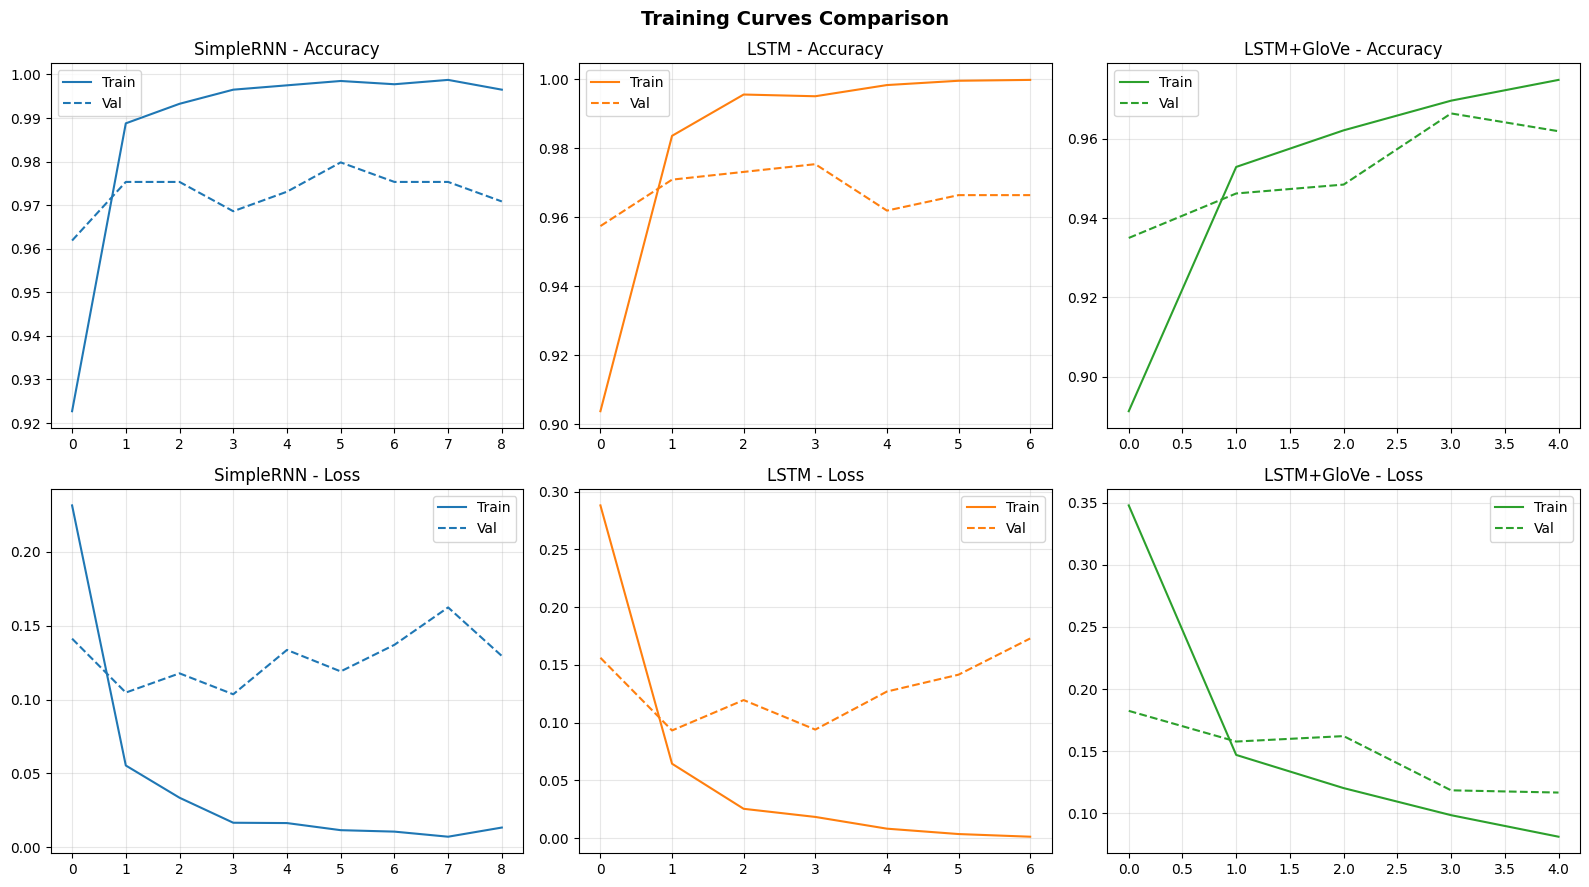

In [17]:
# Training curves for all 3 models
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
info = [(history1,"SimpleRNN",'#1f77b4'),
        (history2,"LSTM",'#ff7f0e'),
        (history3,"LSTM+GloVe",'#2ca02c')]
for col, (h, name, color) in enumerate(info):
    axes[0,col].plot(h.history['accuracy'], label='Train', color=color)
    axes[0,col].plot(h.history['val_accuracy'], label='Val', color=color, linestyle='--')
    axes[0,col].set_title(f"{name} - Accuracy"); axes[0,col].legend(); axes[0,col].grid(alpha=0.3)
    axes[1,col].plot(h.history['loss'], label='Train', color=color)
    axes[1,col].plot(h.history['val_loss'], label='Val', color=color, linestyle='--')
    axes[1,col].set_title(f"{name} - Loss"); axes[1,col].legend(); axes[1,col].grid(alpha=0.3)
plt.suptitle("Training Curves Comparison", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()


 SimpleRNN
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.94      0.81      0.87       149

    accuracy                           0.97      1115
   macro avg       0.96      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



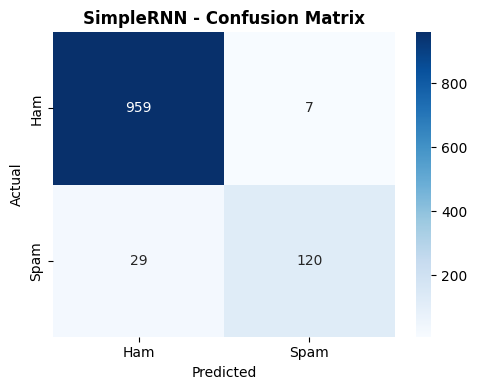


 LSTM
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



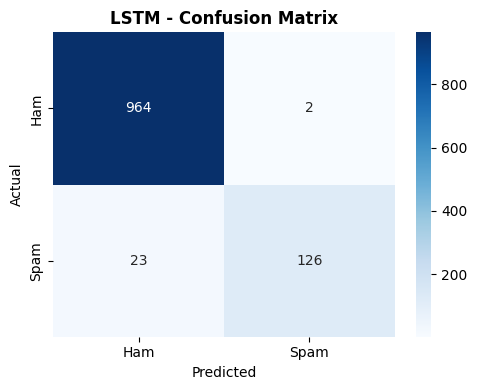


 LSTM GloVe
              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97       966
        Spam       0.82      0.78      0.80       149

    accuracy                           0.95      1115
   macro avg       0.89      0.88      0.89      1115
weighted avg       0.95      0.95      0.95      1115



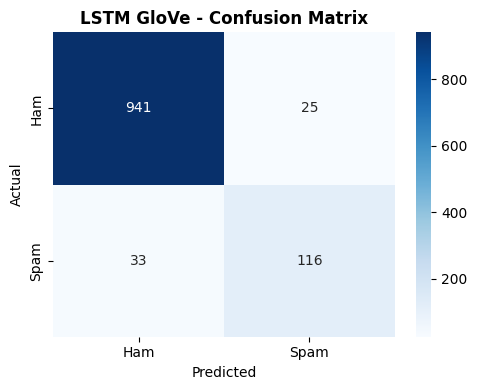

In [18]:
# Evaluate all models
def eval_nlp(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{'='*50}\n {name}\n{'='*50}")
    print(classification_report(y, y_pred, target_names=['Ham','Spam']))
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'], ax=ax)
    ax.set_title(f"{name} - Confusion Matrix", fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.savefig(f"cm_{name.replace(' ','_')}.png", dpi=150); plt.show()
    return accuracy_score(y, y_pred), f1_score(y, y_pred)

acc1, f1_1 = eval_nlp(model1, X_test_pad, y_test, "SimpleRNN")
acc2, f1_2 = eval_nlp(model2, X_test_pad, y_test, "LSTM")
acc3, f1_3 = eval_nlp(model3, X_test_pad, y_test, "LSTM GloVe")

       Model  Accuracy (%)  F1-Score  Train Time(s)
   SimpleRNN         96.77    0.8696           17.2
        LSTM         97.76    0.9097           22.3
LSTM + GloVe         94.80    0.8000           23.9


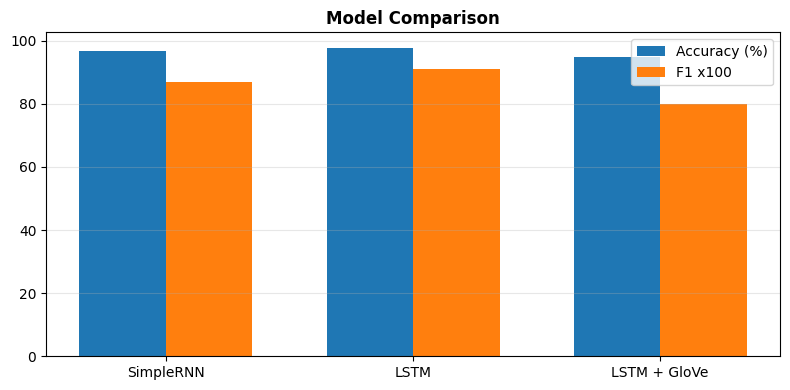

In [19]:
# Summary table
summary = pd.DataFrame({
    'Model':         ['SimpleRNN', 'LSTM', 'LSTM + GloVe'],
    'Accuracy (%)':  [round(acc1*100,2), round(acc2*100,2), round(acc3*100,2)],
    'F1-Score':      [round(f1_1,4), round(f1_2,4), round(f1_3,4)],
    'Train Time(s)': [round(time1,1), round(time2,1), round(time3,1)]
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3); width = 0.35
ax.bar(x-width/2, summary['Accuracy (%)'], width, label='Accuracy (%)', color='#1f77b4')
ax.bar(x+width/2, summary['F1-Score']*100, width, label='F1 x100', color='#ff7f0e')
ax.set_xticks(x); ax.set_xticklabels(summary['Model'])
ax.set_title("Model Comparison", fontweight='bold'); ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig("nlp_comparison.png", dpi=150); plt.show()

## 6. Error Analysis

In [20]:
# Misclassified examples using LSTM (Model 2)
y_prob2 = model2.predict(X_test_pad, verbose=0).flatten()
y_pred2 = (y_prob2 >= 0.5).astype(int)

X_test_list = list(X_test)
y_true_list = list(y_test)
orig_texts = df.loc[X_test.index, 'text'].tolist()

errors = [(orig_texts[i], X_test_list[i], y_true_list[i], y_pred2[i], y_prob2[i])
          for i in range(len(y_true_list)) if y_true_list[i] != y_pred2[i]]

label_map = {0:'Ham', 1:'Spam'}
print(f"Total misclassified: {len(errors)} / {len(y_true_list)}")

# False Positives (Ham wrongly classified as Spam)
fp = [(o, c, t, p, pr) for o, c, t, p, pr in errors if t == 0]
fn = [(o, c, t, p, pr) for o, c, t, p, pr in errors if t == 1]
print(f"False Positives (Ham -> Spam): {len(fp)}")
print(f"False Negatives (Spam -> Ham): {len(fn)}")

print("\n--- 3 False Positives (innocent messages flagged as spam) ---")
for o, c, t, p, pr in fp[:3]:
    print(f"  Msg: '{o[:80]}'")
    print(f"  Confidence: {pr:.2f}\n")

print("--- 3 False Negatives (spam that slipped through) ---")
for o, c, t, p, pr in fn[:3]:
    print(f"  Msg: '{o[:80]}'")
    print(f"  Confidence: {pr:.2f}\n")

Total misclassified: 25 / 1115
False Positives (Ham -> Spam): 2
False Negatives (Spam -> Ham): 23

--- 3 False Positives (innocent messages flagged as spam) ---
  Msg: '\Hey! do u fancy meetin me at 4 at cha åÐ hav a lil beverage on me. if not txt o'
  Confidence: 0.52

  Msg: 'We have sent JD for Customer Service cum Accounts Executive to ur mail id, For d'
  Confidence: 0.74

--- 3 False Negatives (spam that slipped through) ---
  Msg: 'FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some'
  Confidence: 0.06

  Msg: 'Talk sexy!! Make new friends or fall in love in the worlds most discreet text da'
  Confidence: 0.07

  Msg: 'Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next wee'
  Confidence: 0.29



In [21]:
# Model complexity vs performance
print("=== Model Complexity vs Performance ===")
print(f"SimpleRNN: {model1.count_params():,} params | Acc: {acc1*100:.2f}% | F1: {f1_1:.4f}")
print(f"LSTM:      {model2.count_params():,} params | Acc: {acc2*100:.2f}% | F1: {f1_2:.4f}")
print(f"LSTM+GloVe:{model3.count_params():,} params | Acc: {acc3*100:.2f}% | F1: {f1_3:.4f}")
print()
print("Possible reasons for errors:")
print("1. False Positives: Messages with spam-like words (free, win, prize) but sent by")
print("   friends. Context and sender identity cannot be captured by word-level models.")
print("2. False Negatives: Sophisticated spam that avoids common spam keywords,")
print("   uses abbreviations (ur, txt, gr8) not well represented in GloVe vocabulary.")
print("3. Imbalanced data: Model trained on 87% ham - biased toward predicting ham.")
print()
print("Suggested improvements:")
print("- Use class_weight to penalize errors on spam more heavily")
print("- Oversample spam using SMOTE on text features")
print("- Try Bidirectional LSTM for better context understanding")
print("- Add character-level features to handle SMS abbreviations")

=== Model Complexity vs Performance ===
SimpleRNN: 650,369 params | Acc: 96.77% | F1: 0.8696
LSTM:      686,529 params | Acc: 97.76% | F1: 0.9097
LSTM+GloVe:542,945 params | Acc: 94.80% | F1: 0.8000

Possible reasons for errors:
1. False Positives: Messages with spam-like words (free, win, prize) but sent by
   friends. Context and sender identity cannot be captured by word-level models.
2. False Negatives: Sophisticated spam that avoids common spam keywords,
   uses abbreviations (ur, txt, gr8) not well represented in GloVe vocabulary.
3. Imbalanced data: Model trained on 87% ham - biased toward predicting ham.

Suggested improvements:
- Use class_weight to penalize errors on spam more heavily
- Oversample spam using SMOTE on text features
- Try Bidirectional LSTM for better context understanding
- Add character-level features to handle SMS abbreviations
